##### ***从Full Fine-tuning到LoRA与RLoRA***
###### 在正式进入现代主流的微调方案PEFT之前，我们需要先简单回顾一下最直接的微调方式，Full Fine-tuning，所谓的Full Fine-tuning指在预训练模型的基础上，将模型中的全部参数都继续参与训练，从而让模型逐渐适应某些具体的下游任务，也就是说模型并不会冻结训练好的参数，而是将全部参数都继续通过前向传播、损失计算、反向传播和参数更新来完成下游任务的适配。
###### 由于有了预训练模型参数的基础，所以虽然Full Fine-tuning给人的感觉是重新训练了一遍模型，但是其实它在已有参数的基础上稍作调整，所以是在通用能力的基础上进行定向调整，这种方法的优点在于简单直接不需要设计新的模块，但是缺点也十分明显，由于模型的全部参数都要参与梯度更新，因此对算力、显存和存储的要求都很高，尤其是在大模型的参数越来越大的背景下，这种方式往往会带来巨大的训练成本，并且，如果每个任务都要采用全参数微调，那么每个任务都需要单独保存一整份模型权重，这在实际应用中也会造成巨大的存储开销。
###### 所以Full Fine-tuning仅做了解，PEFT才是目前的主流微调手段，其中LoRA和QLoRA便是两种最具代表性的方法。
##### ***LoRA(Low-Rank Adaptation)***
###### 在大模型微调的实践中，人们很快发现，Full Fine-tuning虽然简单直接，但代价实在过高。对于参数量较小的模型来说，更新全部参数尚且可以接受；但当模型规模上升到数十亿甚至数百亿参数时，显存占用、训练成本以及模型存储都会迅速膨胀。于是，一个非常自然的问题出现了：既然预训练模型已经具备较强的通用能力，那么在面对新任务时，我们是否真的需要重新调整全部参数？LoRA正是在这样的背景下被提出的。LoRA全称为Low-Rank Adaptation，即“低秩适配”。它的核心思想是：冻结原始预训练权重，只额外训练一个规模很小的低秩更新矩阵，用它来近似表示任务所需的参数变化。 这样一来，我们就不必再更新整个模型，而只需要训练少量新增参数，就能够让模型适应新的任务场景。
###### 其核心思想在于研究者们发现，预训练好的大模型是高度过参数化的，也就是说此时的模型拥有一个良好的泛化解空间，在适配新任务的时候真正需要的有效变化方向其实很少，不需要调整所有权重维度，而Aghajanyan的研究也表明，预训练模型拥有一个极小的内在维度（Intrinsic Dimension），模型的参数变化可以被限制在一个非常低维的子空间。所以基于这一观察，LoRA提出不直接更新全部参数$W^{m \times n}$，而是额外引入两个小矩阵$A^{m \times r}$和$B^{r \times n}$，其中$r \leq \min(m, n)$。所以前向传播变为：$$h = W_x + \Delta W_x = W_x + BA$$
###### 训练时只更新$A$和$B$，而原始权重则保持不变，由于$r$的取值很小通常为4、8或16，可训练的参数量就从$m \times n$骤减至$m \times r + r \times n$，极大的降低了显存和存储开销。由于线性变换的特性，可以直接将$\Delta W_x$合并到原参数，这样在推理时就没有额外的计算开销，也不用存储额外的两个矩阵。但只能在线性层上做此合并。

##### ***用代码理解LoRA***
###### 理解了原理之后，我们用一个最小实现来真正看懂LoRA在做什么。这里我们定义一个`LoRALinear`类，它接收一个普通的线性层，并在其基础上加入LoRA模块。在训练时，原始权重被冻结，只有两个低秩矩阵参与更新；推理时则可以直接把低秩增量合并回原权重，不产生额外计算开销。
###### 其中有一些工程细节：
1. 实现一个新的LoRALinear类组合原始权重 + 低秩矩阵。
2. 训练时冻结原始权重
3. 关于B A矩阵的初始化，B矩阵选择零初始化而A选择随机初始化，目的是为了保证初始输出=原始输出，后一点点优化，使训练更稳。（一般靠近输入端的使用随机初始化，靠近输出端的使用零初始化。也就是说谁先跟输入进行计算，谁就使用随机初始化）
4. 工程实现中需要加入缩放因子$\alpha$，即$\alpha/r$

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, rank=4, alpha=1.0):
        super().__init__()
        # 1.原始训练权重冻结
        self.linear = nn.Linear(in_features,out_features, bias=False)
        self.linear.weight.requires_grad = False

        # 2.LoRA额外矩阵
        # A:随机初始化，高斯分布，标准差0.01
        self.LoRA_A = nn.Parameter(torch.randn(in_features, rank) * 0.01)
        # B:全零初始化
        self.LoRA_B = nn.Parameter(torch.zeros(rank, out_features))

        self.rank = rank
        self.alpha = alpha

    def forward(self, x):
        base_out = F.linear(x, self.linear.weight, self.linear.bias)

        lora_out = (x @ self.LoRA_A) @ self.LoRA_B
        lora_out *= (self.alpha / self.rank)

        return base_out + lora_out

    def merge(self):
        # 将LoRA分支合并到原始权重中，推理加速
        with torch.no_grad():
            detla_w = (self.LoRA_A @ self.LoRA_B) * (self.alpha / self.rank)

            self.linear.weight.data += detla_w.T
            self.LoRA_A.data.zero_()
            self.LoRA_B.data.zero_()
        


In [25]:
# 构造一个模拟的预训练模型
class PretrainedMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(16, 32, bias = False)
        self.fc2 = nn.Linear(32, 8, bias=False)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

pretrained = PretrainedMLP()
print(f"原始 fc2 权重的范数: {pretrained.fc2.weight.norm().item():.4f}")

原始 fc2 权重的范数: 1.6127


In [26]:
# 用LoRA替换
class LoRAPretrainedMLP(nn.Module):
    def __init__(self, base_model, rank=4, alpha=8.0):
        super().__init__()
        self.fc1 = base_model.fc1
        in_features = base_model.fc2.in_features
        out_features = base_model.fc2.out_features
        self.fc2 = LoRALinear(in_features, out_features, rank, alpha)

        with torch.no_grad():
            self.fc2.linear.weight.data = base_model.fc2.weight.data.clone()

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = LoRAPretrainedMLP(pretrained, rank=2, alpha=4)

In [27]:
total_params = 0
trainable_params = 0
for name, p in model.named_parameters():
    print(f"{name}: {p.shape} -> requires_grad={p.requires_grad}")
    total_params += p.numel()
    if p.requires_grad:
        trainable_params += p.numel()

print(f"\n总参数量: {total_params}")
print(f"可训练参数量: {trainable_params}")
print(f"可训练比例: {trainable_params / total_params:.2%}")

fc1.weight: torch.Size([32, 16]) -> requires_grad=True
fc2.LoRA_A: torch.Size([32, 2]) -> requires_grad=True
fc2.LoRA_B: torch.Size([2, 8]) -> requires_grad=True
fc2.linear.weight: torch.Size([8, 32]) -> requires_grad=False

总参数量: 848
可训练参数量: 592
可训练比例: 69.81%


In [28]:
# 生成假数据
batch_size = 8
x = torch.randn(batch_size, 16)
y = torch.randint(0, 8, (batch_size,))  # 假设是 8 分类任务

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)  # 只优化 LoRA 参数

# 训练前测一下损失
with torch.no_grad():
    logits_before = model(x)
    loss_before = criterion(logits_before, y)
print(f"训练前 Loss: {loss_before.item():.4f}")

# 训练 20 步
for step in range(20):
    optimizer.zero_grad()
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    if step % 5 == 0:
        print(f"Step {step}, Loss: {loss.item():.4f}")

# 训练后测一下损失
with torch.no_grad():
    logits_after = model(x)
    loss_after = criterion(logits_after, y)
print(f"训练后 Loss: {loss_after.item():.4f}")

训练前 Loss: 2.1778
Step 0, Loss: 2.1778
Step 5, Loss: 1.8144
Step 10, Loss: 1.4367
Step 15, Loss: 0.9802
训练后 Loss: 0.6305


In [29]:
# 保存合并前的参数范数（用于对比）
lora_A_norm_before = model.fc2.LoRA_A.norm().item()
lora_B_norm_before = model.fc2.LoRA_B.norm().item()
print(f"合并前 lora_A 范数: {lora_A_norm_before:.6f}")
print(f"合并前 lora_B 范数: {lora_B_norm_before:.6f}")

# 执行合并
model.fc2.merge()

# 检查合并后的 LoRA 参数是否被清零了
lora_A_norm_after = model.fc2.LoRA_A.norm().item()
lora_B_norm_after = model.fc2.LoRA_B.norm().item()
print(f"合并后 lora_A 范数: {lora_A_norm_after:.6f}")
print(f"合并后 lora_B 范数: {lora_B_norm_after:.6f}")

# 验证合并前后模型输出是否一致（关键测试！）
with torch.no_grad():
    # 注意：合并后，LoRALinear 的前向逻辑变了（因为 lora_A 和 lora_B 被清零了）
    # 但合并时已经把 BA 加到了 linear.weight 里，所以输出应该和合并前完全一样。
    # 为了公平对比，我们需要用同一个输入，但合并前我们没保存输出。
    # 重新算一遍：
    test_x = torch.randn(4, 16)
    model_copy = LoRAPretrainedMLP(pretrained, rank=2, alpha=4.0)  # 新建一个没合并的模型
    # 把前面训练好的权重拷贝给这个新模型（略复杂，我们直接验证合并后模型输出是否等于“原始 + LoRA”的计算方式）
    
    # 更简单的验证：在合并前，我们手动计算一次输出，合并后再算一次。

合并前 lora_A 范数: 1.353606
合并前 lora_B 范数: 0.743874
合并后 lora_A 范数: 0.000000
合并后 lora_B 范数: 0.000000


##### ***QLoRA(Quantized Low-Rank Adaptation)***
###### 作为LoRA的升级版，其在LoRA的基础上进一步加入了4-bit量化技术，将需要微调的庞大模型先一步压缩为内存占用更小的压缩版，极大的降低了微调所需要的硬件门槛。
###### 举个例子，如果加载一个7B的参数模型，其16-bit半精度权重仍然需要约14GB显存，开销巨大，但使用了4-bit量化后，将原来的权重占用降低到了1/4倍，最后模型的显存占用骤降至3.5GB，所以能在小显存的GPU上进行微调。
###### 关于4-bit量化，由于本人并不是专业的量化算法研究员，所以仅简单讲解QLoRA中的量化操作，其他细节请自行查阅相关文献。
###### 首先先了解最基础的线性量化，即从一组浮点数中挑选出绝对值最大的数值，构建映射区间，然后按照需要转变的bit数将其等距离划分成不同的数值区间，接着将浮点数放进不同的区间，得到其索引。但是这种方法最大的缺点是均分切分导致输入的划分并不均匀，因为LLM的权重并不是均匀分布的，它们集中在0附近，符合正态分布所以QLoRA使用其他的量化手段。
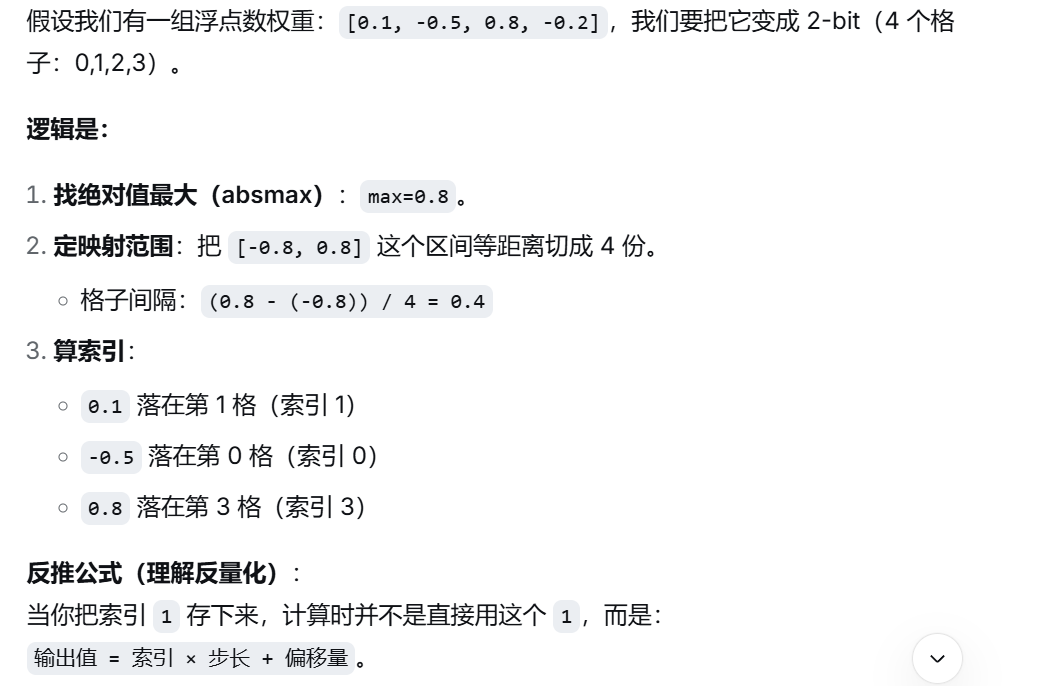
###### NF4（NormalFloat 4-bit）量化。所以QLoRA使用另一种量化手段：按概率密度划分。具体做法是假设权重服从正态分布，然后将正态分布的曲线面积等分为16份（因为4-bit有16种情况），找到每一份的边界值，然后按线性量化的手段将浮点数放入对应区间得到索引即可。在权重密集的 0 附近，格子的间距非常小，精度极高；在权重稀疏的远距离端，格子间距很大，精度降低。这正好完美适配了大模型的权重分布，所以 NF4 几乎没有精度损失。
###### 有了NF4量化手段后，仍需考虑一些特殊情况。由于LLM权重里偶尔会出现巨大的离群值，这个值一般和其他权重不是一个量级，为了容纳这个值，会导致步长变得极大导致0附近的所有权重的分辨率丢失。QLoRA的解决方案是使用分块量化，也就是将整个权重矩阵切分成很多小块，每个小块通常包含64个权重，每一块算自己的最大绝对值，自己决定自己的量化格子。存储时，除了存储这 64 个 4-bit 索引，还额外存储一个 16-bit 的缩放因子（Block-wise Scaling Factor），用于还原这一块的“真实步长”。因为每一个块的绝对长度是不同的
###### 即使使用了 NF4，量化过程中产生的缩放因子（每 64 个权重共享一个 32-bit 的缩放因子）本身也会占用不少显存。为了解决这个问题，QLoRA 采用“双重量化”：对这些 32-bit 的缩放因子再进行一次量化（例如，每 256 个缩放因子使用 8-bit 存储）。
###### 在训练时，优化器状态（如 Adam 的动量和方差）往往比模型本身更占显存。QLoRA 利用 NVIDIA 统一内存技术，在 GPU 显存紧张时，会自动将优化器状态分页并转移到 CPU 内存中，从而避免显存溢出（OOM）错误。

##### ***QLoRA的代码结构***
###### 由于4-bit量化依赖bitsandbytes等库，底层工程细节较多，且本机为CPU环境，因此这里不展开可运行的完整实现，只梳理QLoRA训练代码的骨架与每个部分的作用。QLoRA的训练代码本质上由五步组成：量化配置、加载4-bit模型、LoRA配置、挂载LoRA、确认可训练参数。
###### 第一步，量化配置。使用BitsAndBytesConfig来决定模型本体以多低的比特存储。其中`load_in_4bit=True`表示以4-bit形式加载；`bnb_4bit_quant_type="nf4"`表示使用NF4量化格式；`bnb_4bit_use_double_quant=True`表示对量化过程的缩放因子再量化一次，进一步节省空间；`bnb_4bit_compute_dtype`则表示实际计算时使用的精度。
```python
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)
```
###### 第二步，加载4-bit模型。加载时把量化配置传入`quantization_config`，模型就会以4-bit形式载入，从而大幅降低显存占用。这一阶段模型本体是量化且冻结的状态，并不会参与训练。
```python
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    "模型名称",
    quantization_config=bnb_config,
)
```
###### 第三步，LoRA配置。这里的LoraConfig与前文手写的LoRALinear一一对应：`r`对应低秩矩阵的秩，`lora_alpha`对应缩放系数alpha，`target_modules`指定LoRA挂在哪些线性层上，`lora_dropout`对应dropout。
```python
from peft import LoraConfig

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
)
```
###### 第四步，挂载LoRA。`get_peft_model`会把LoRA配置作用到模型上，等价于批量地把指定线性层替换成带LoRA分支的版本，而原始权重保持冻结。
```python
from peft import get_peft_model

model = get_peft_model(model, lora_config)
```
###### 第五步，确认可训练参数。`print_trainable_parameters`会打印整个模型中可训练参数的比例，用于验证QLoRA的核心目标：只训练极小比例的LoRA参数，而模型本体保持量化冻结。
```python
model.print_trainable_parameters()
# 输出类似：trainable params: 4,194,304 || all params: 7,000,000,000 || trainable: 0.06%
```
###### 总的来说，QLoRA的代码框架可以看作是：用BitsAndBytesConfig实现4-bit量化加载，用LoraConfig描述LoRA参数，再用get_peft_model把两者组装到一起。它相比手写LoRA只多了一步量化，而LoRA本身的参数含义与前文完全一致。

In [ ]:
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    TaskType
)
from datasets import load_dataset
import os

In [ ]:
# 配置4-bit量化参数
bnb_config = BitsAndBytesConfig(
    load_in_4bit = True,
    bnb_4bit_quant_type = "nf4",
    bnb_4bit_use_double_quant = True,
    bnb_4bit_compute_dtype = torch.bfloat16 # 计算时使用BF16稳定且省显存
)

In [ ]:
# 以Qwen2-0.5B为例
model_name = "Qwen/Qwen2-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code = True
)

In [ ]:
# 对量化模型进行预处理（这是 QLoRA 的关键一步）
model = prepare_model_for_kbit_training(model)
# prepare_model_for_kbit_training 会：将某些层（如 LayerNorm）转回全精度，防止梯度消失。启用梯度检查点（节省显存）。

In [ ]:
# LoRA 配置
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,          # 因果语言模型（GPT 类）
    r=8,                                   # 秩
    lora_alpha=32,                         # 缩放系数
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # 对 Attention 的 Q、K、V、O 加 LoRA
    lora_dropout=0.05,
    bias="none",
)

# 应用 LoRA
model = get_peft_model(model, lora_config)

# 打印可训练参数数量（验证 LoRA 生效）
model.print_trainable_parameters()

In [ ]:
# 加载数据集
dataset = load_dataset("Abirate/english_quotes", split="train")

# 格式化数据：每个样本变成 "quote: <quote>"
def format_func(example):
    return {"text": f"quote: {example['quote']}"}

dataset = dataset.map(format_func)

# 分词函数
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128,
        padding=False,
        return_tensors=None
    )

tokenized_dataset = dataset.map(tokenize_function, remove_columns=dataset.column_names)

In [ ]:
# 训练参数
training_args = TrainingArguments(
    output_dir="./qlora-output",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    logging_steps=10,
    save_steps=50,
    fp16=True,
    report_to="none",  # 不向 wandb 报告
    remove_unused_columns=False,
)

# 数据整理器（将批次填充到相同长度）
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,          # 因果语言模型，不是 MLM
)

# 创建训练器
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
)

# 开始训练
trainer.train()

In [ ]:
# 保存 LoRA 适配器权重（非常小，几 MB 到几十 MB）
model.save_pretrained("./qlora-lora-adapter")
tokenizer.save_pretrained("./qlora-lora-adapter")

In [ ]:
from peft import PeftModel

# 重新加载基座模型（4-bit）
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

# 加载 LoRA 适配器
model = PeftModel.from_pretrained(base_model, "./qlora-lora-adapter")

# 推理测试
prompt = "quote: "
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
outputs = model.generate(
    **inputs,
    max_new_tokens=50,
    temperature=0.7,
    do_sample=True
)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

In [ ]:
# 合并 LoRA 到基座模型
merged_model = model.merge_and_unload()

# 保存完整模型（可能较大，但推理速度更快）
merged_model.save_pretrained("./qlora-merged-model")
tokenizer.save_pretrained("./qlora-merged-model")